In [38]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

In [39]:
env = gym.make('MountainCar-v0')

In [40]:
def random_strategy():
    observation, reward = env.reset()

    reward_arr = []

    for _ in range(200):
        observation, reward, terminated, truncated, info = env.step(env.action_space.sample())

        reward_arr.append(reward)

        if terminated or truncated:
            env.close()
            return reward_arr

    env.close()
    return reward_arr


mean: -200.0
Standard Deviation: 0.0


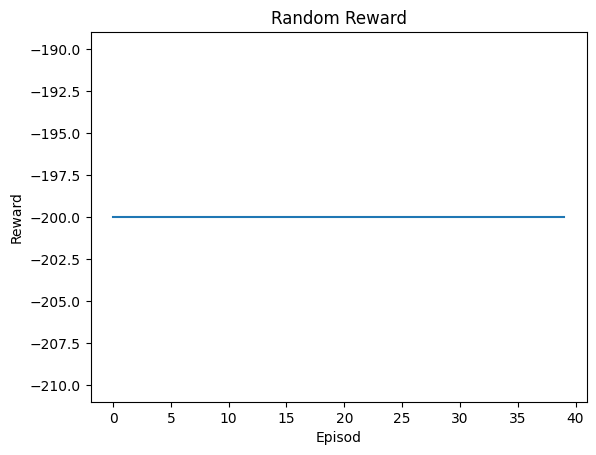

In [41]:
random_reward_arr = []

for _ in range(40):
    random_reward = random_strategy()
    random_reward_arr.append(sum(random_reward)) 


print('mean:', np.mean(random_reward_arr))
print('Standard Deviation:', np.std(random_reward_arr))
plt.plot(random_reward_arr)
plt.xlabel('Episod')
plt.ylabel('Reward')
plt.title('Random Reward')
plt.show()

In [42]:
def simple_strategy():
    observation, reward = env.reset()

    reward_arr = []
    v = observation[1]

    for _ in range(200):
        
        if v < 0:
            action = 0
        else:
            action = 2

        observation, reward, terminated, truncated, info = env.step(action)

        reward_arr.append(reward)

        v = observation[1]

        if terminated or truncated:
            env.close()
            return reward_arr

    env.close()
    return reward_arr

mean: -120.175
Standard Deviation: 3.2240308621351628


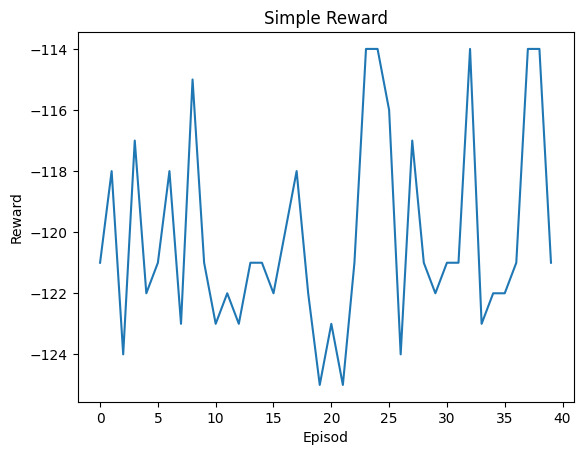

In [43]:
simple_reward_arr = []

for _ in range(40):

    simple_reward = simple_strategy()
    simple_reward_arr.append(sum(simple_reward))

print('mean:', np.mean(simple_reward_arr))
print('Standard Deviation:', np.std(simple_reward_arr))
plt.plot(simple_reward_arr)
plt.xlabel('Episod')
plt.ylabel('Reward')
plt.title('Simple Reward')
plt.show()


In [44]:
def semi_random():
    observation, reward = env.reset()

    reward_arr = []
    v = observation[1]
    
    for _ in range(200):

        if v > 0.02:
            observation, reward, terminated, truncated, info = env.step(2)
        elif v < -0.02:
            observation, reward, terminated, truncated, info = env.step(0)
        else:
            observation, reward, terminated, truncated, info = env.step(env.action_space.sample())

        reward_arr.append(reward)

        v = observation[1]

        if terminated or truncated:
            env.close()
            return reward_arr

    env.close()
    return reward_arr

mean: -197.925
Standard Deviation: 9.061974122673272


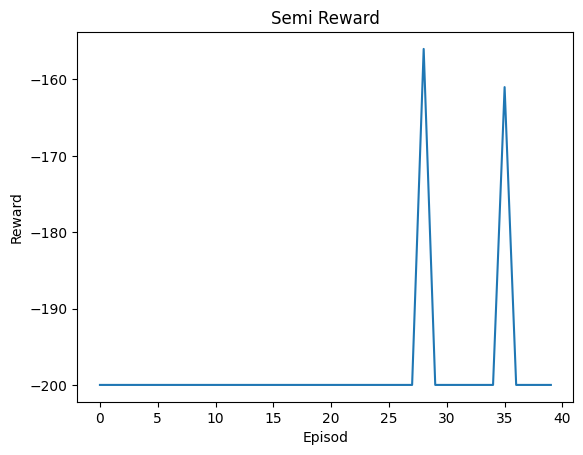

In [81]:
semi_reward_arr = []

for _ in range(40):

    semi_reward = semi_random()
    semi_reward_arr.append(sum(semi_reward))

print('mean:', np.mean(semi_reward_arr))
print('Standard Deviation:', np.std(semi_reward_arr))
plt.plot(semi_reward_arr)
plt.xlabel('Episod')
plt.ylabel('Reward')
plt.title('Semi Reward')
plt.show()